#  House Price Prediction using Machine Learning

##  Project Overview
This project aims to predict house prices using machine learning regression techniques. 
The dataset contains various house-related features such as bedrooms, bathrooms, 
square footage, and other structural attributes.

The objective is to build a regression model and evaluate its performance 
using MAE and RMSE metrics.

##  Importing Required Libraries

We import essential libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine Learning (scikit-learn)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

##  Loading the Dataset

The dataset is loaded using pandas into a DataFrame 
for further analysis and preprocessing.

In [4]:
data = pd.read_csv("data.csv")
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


##  Dataset Overview

We check:
- Number of rows and columns
- Data types
- Missing values

In [5]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

##  Data Cleaning

We remove unnecessary columns such as:
- date
- street
- city
- statezip
- country

These columns are either non-numeric or not directly useful 
for regression modeling.

In [7]:
data = data.drop(['date','street','city','statezip','country'], axis=1)

##  Handling Missing Values

Missing values are removed to ensure clean data 
for training the machine learning model.

In [8]:
data = data.dropna()

##  Defining Features and Target Variable

 - X for Input features
 - y for Target variable (price)

In [9]:
X = data.drop('price', axis=1)
y = data['price']

##  Splitting the Dataset

The dataset is split into:
- 80% Training data
- 20% Testing data

This ensures the model is evaluated on unseen data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Training – Linear Regression

We train a Linear Regression model to predict house prices 
based on numerical features.

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##  Making Predictions

The trained model is used to predict prices 
on the test dataset.

In [12]:
y_pred = model.predict(X_test)

##  Model Evaluation

We evaluate performance using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Lower values indicate better model performance.

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 210908.1732501275
RMSE: 993439.3625461733


##  Result Interpretation

MAE represents the average absolute difference 
between actual and predicted prices.

RMSE penalizes larger errors more heavily 
and provides a better understanding of model accuracy.

The obtained results indicate that the model performs reasonably well 
for predicting house prices.

##  Actual vs Predicted Prices Visualization

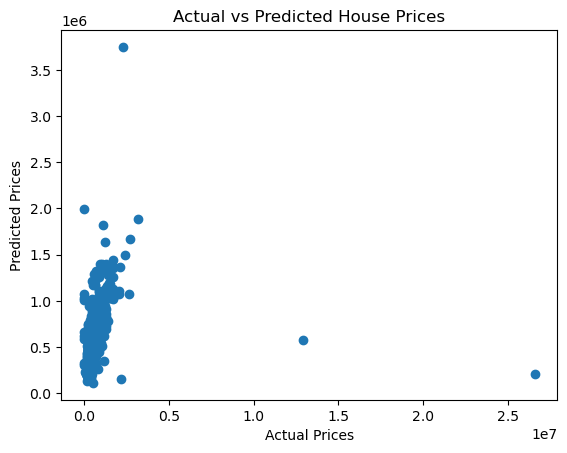

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Heatmap

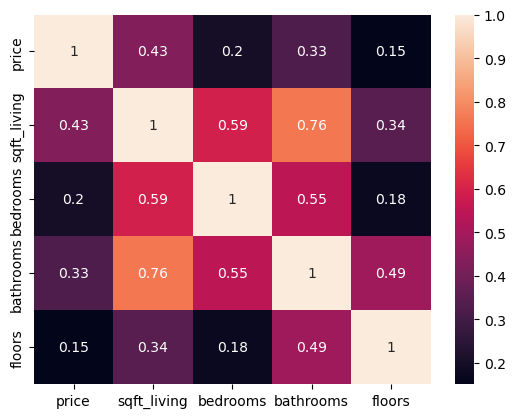

In [17]:
sns.heatmap(data[["price", "sqft_living", "bedrooms", "bathrooms", "floors"]].corr(), annot = True)
plt.show()

## use seaborn library to visualize the attribute price

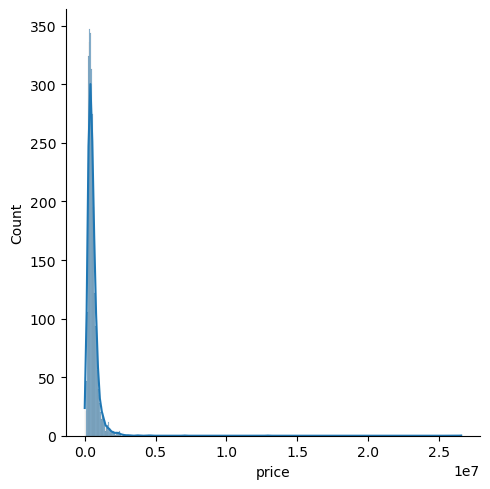

In [21]:
sns.displot(data['price'], kind='hist', kde=True)
plt.show()

##  Conclusion

A Linear Regression model was successfully implemented to predict house prices.
The model demonstrated reasonable predictive performance based on MAE and RMSE metrics.
Exploratory data analysis revealed that living area size is the strongest predictor of price.
While the current model performs well, future improvements such as advanced algorithms 
and feature engineering could further enhance prediction accuracy.